<a href="https://www.kaggle.com/code/lalit7881/credit-card-fraud-eda?scriptVersionId=324898932" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ranafayezz/credit-card-fraud/credit_card_fraud_synthetic.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ranafayezz/credit-card-fraud/credit_card_fraud_synthetic.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0


In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,Amount,Class
995,150168,-0.239297,-0.093612,0.674449,-1.934307,0.201932,1863.34,0
996,67728,-0.717823,0.704535,0.347665,0.158832,-0.295808,1152.10,0
997,165088,-0.484361,1.489765,-0.921505,-0.624253,1.588061,2805.25,0
998,11246,1.053057,-0.885100,-0.391480,0.000222,-0.077757,672.88,0
999,149453,2.033305,1.457079,-0.159335,1.651450,-0.186564,1601.27,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   Amount  1000 non-null   float64
 7   Class   1000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,Amount,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,86194.539000,0.017610,0.069906,-0.022792,0.022354,-0.013218,2577.052080,0.018000
std,50008.474586,1.038301,1.035560,0.992346,0.978387,0.998908,1444.284318,0.133018
min,235.000000,-3.568205,-2.913672,-3.239438,-2.936162,-3.708797,25.890000,0.000000
25%,42052.250000,-0.646795,-0.594730,-0.693360,-0.624690,-0.711692,1358.502500,0.000000
50%,89361.500000,0.031403,0.089010,-0.008512,-0.000167,0.019587,2636.405000,0.000000
75%,127614.750000,0.742573,0.759734,0.666350,0.664478,0.686529,3849.640000,0.000000
max,172627.000000,3.174442,3.260491,2.750723,3.657702,2.840886,4998.710000,1.000000


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
Amount    float64
Class       int64
dtype: object

In [10]:
df.shape

(1000, 8)

In [11]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class'], dtype='object')

In [12]:
df.nunique()

Time       999
V1        1000
V2        1000
V3        1000
V4        1000
V5        1000
Amount     999
Class        2
dtype: int64

In [13]:
df.dtypes

Time        int64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
Amount    float64
Class       int64
dtype: object

## EDA

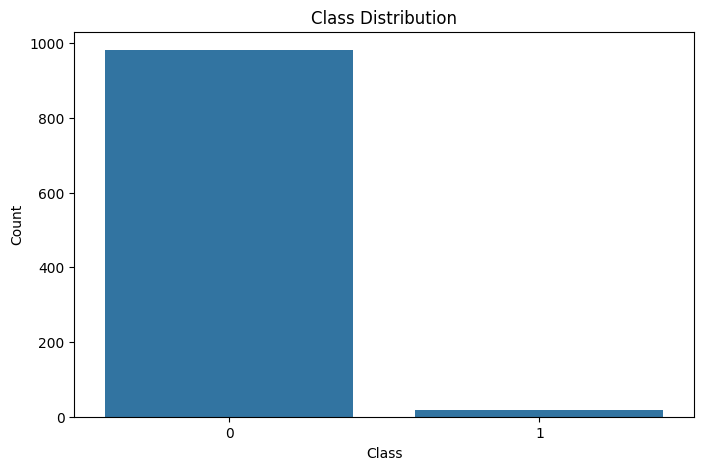

Class
0    982
1     18
Name: count, dtype: int64
Class
0    98.2
1     1.8
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Class',
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df['Class'].value_counts())

print(
    df['Class'].value_counts(normalize=True)*100
)

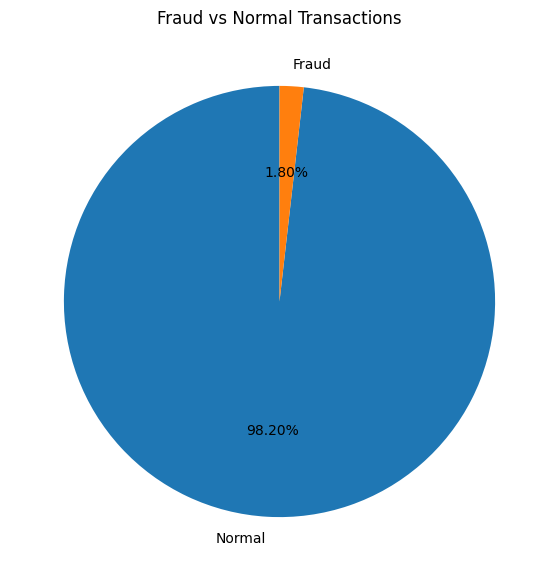

In [15]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    class_counts,
    labels=['Normal','Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Fraud vs Normal Transactions")
plt.show()

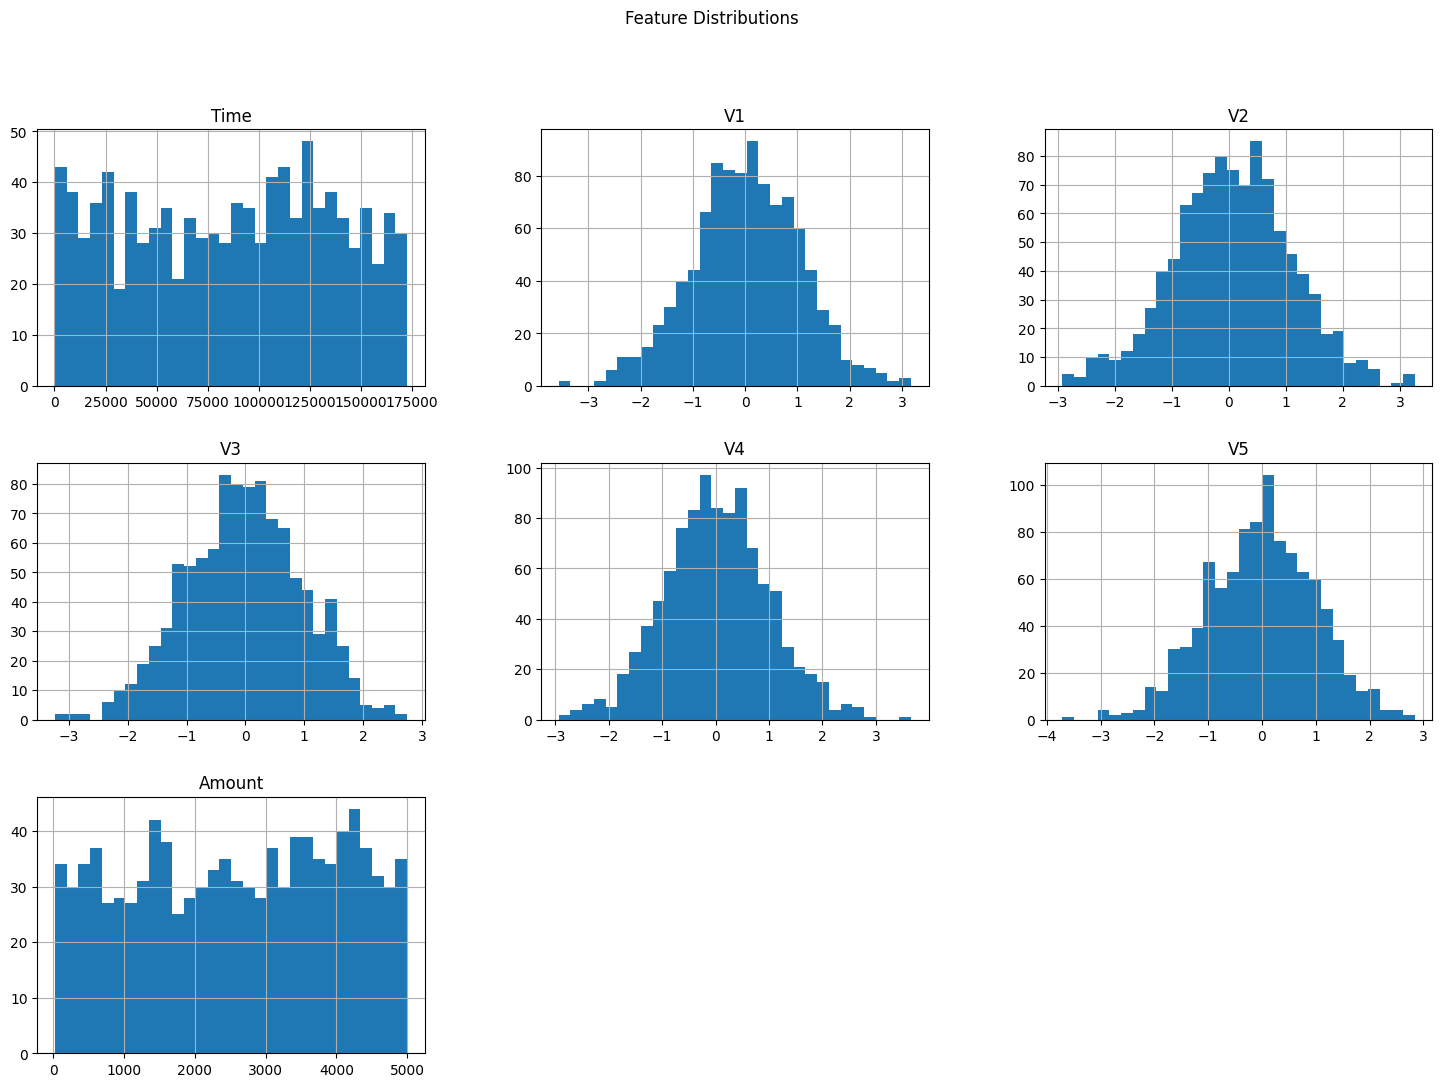

In [16]:
num_cols = ['Time','V1','V2','V3','V4','V5','Amount']

df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.suptitle("Feature Distributions")
plt.show()

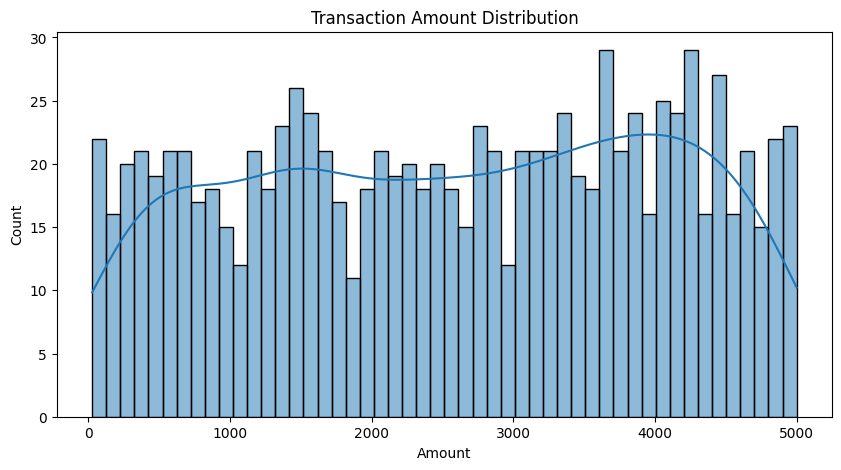

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Amount'],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.show()

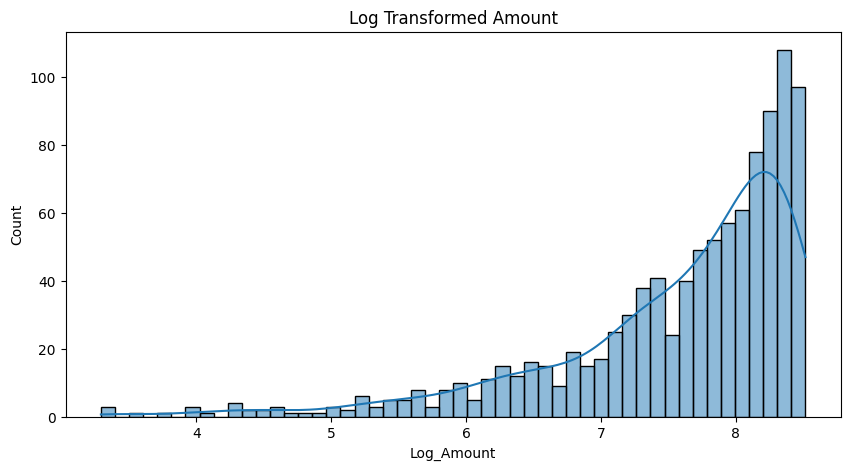

In [18]:
df['Log_Amount'] = np.log1p(df['Amount'])

plt.figure(figsize=(10,5))

sns.histplot(
    df['Log_Amount'],
    bins=50,
    kde=True
)

plt.title("Log Transformed Amount")
plt.show()

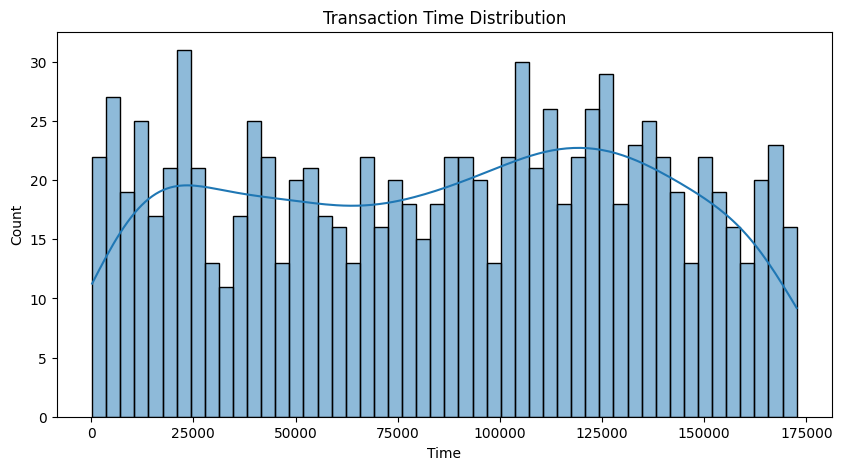

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Time'],
    bins=50,
    kde=True
)

plt.title("Transaction Time Distribution")
plt.show()

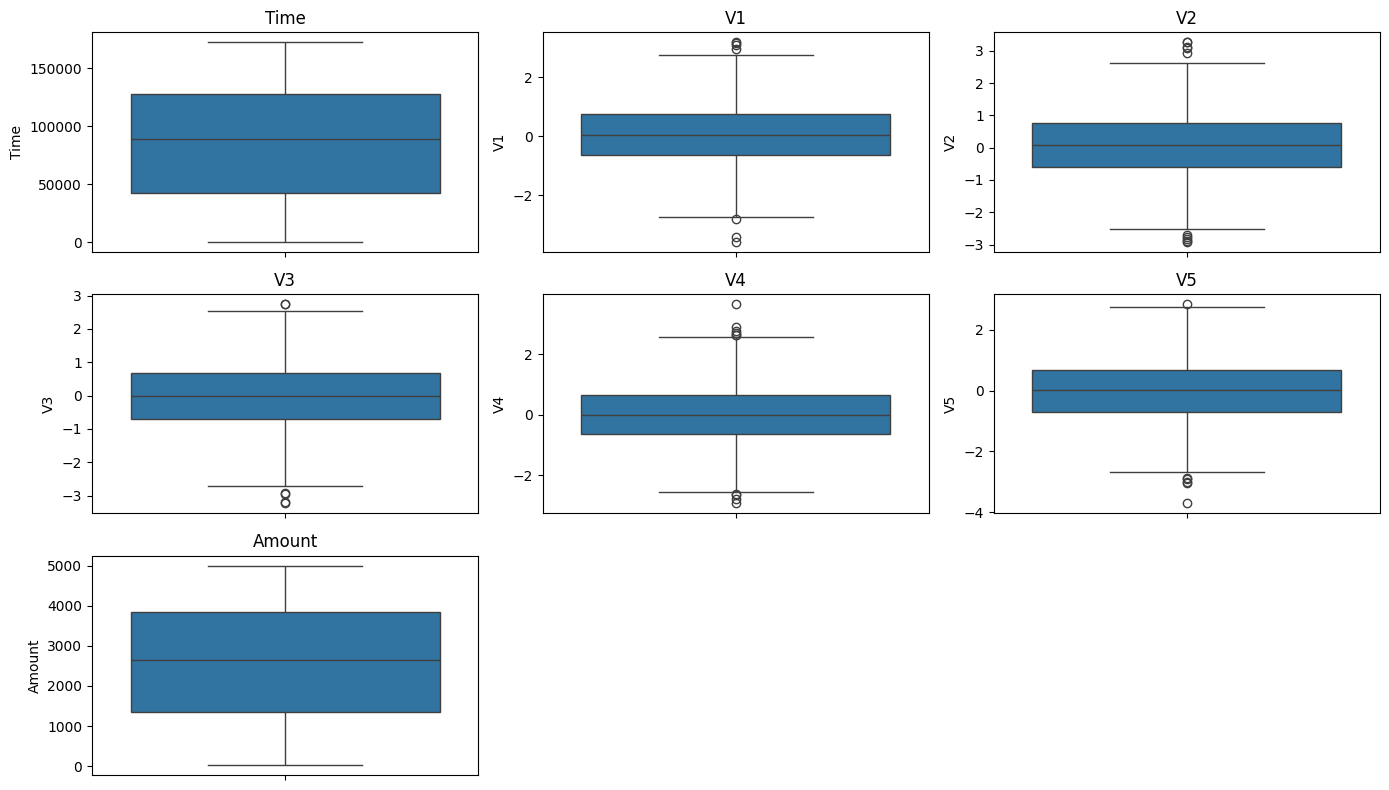

In [20]:
plt.figure(figsize=(14,8))

for i,col in enumerate(num_cols,1):

    plt.subplot(3,3,i)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

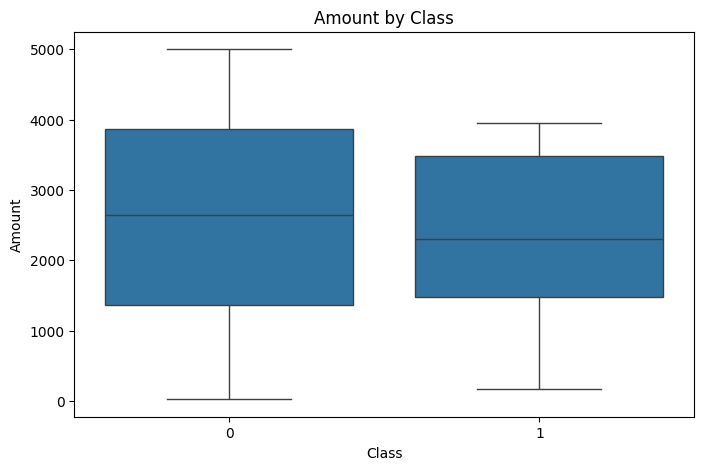

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.title("Amount by Class")
plt.show()

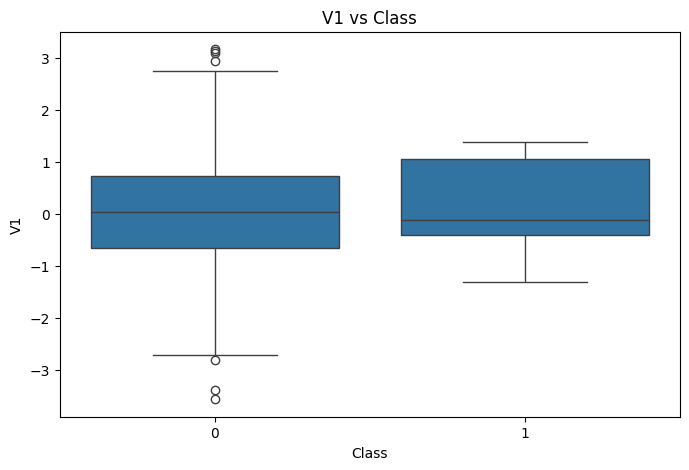

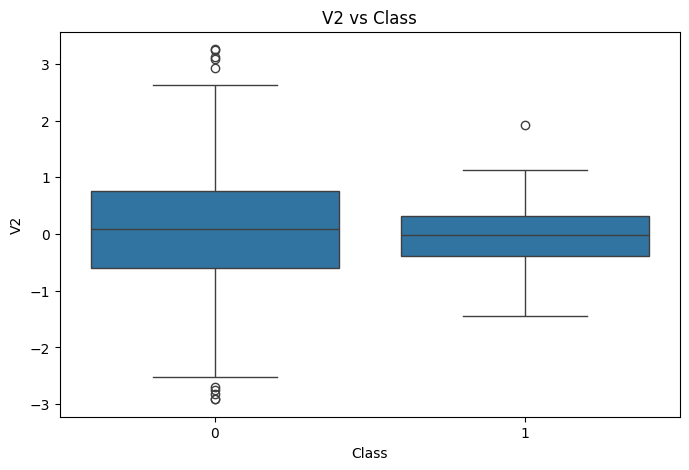

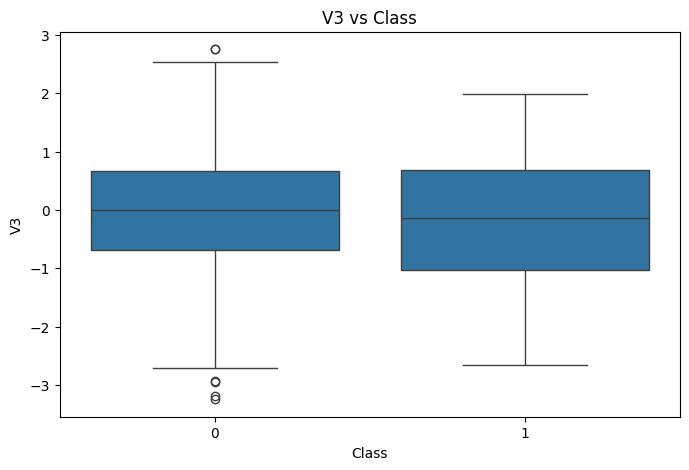

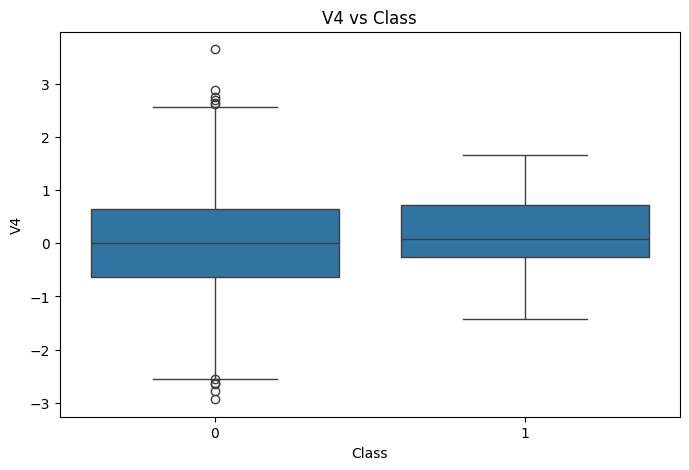

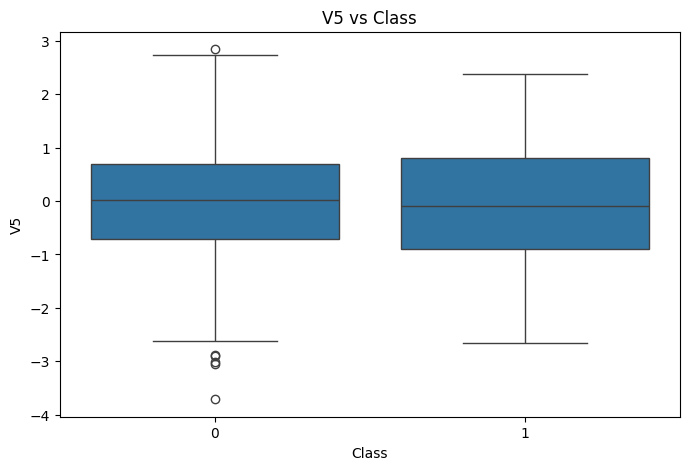

In [22]:
features = ['V1','V2','V3','V4','V5']

for col in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='Class',
        y=col,
        data=df
    )

    plt.title(f"{col} vs Class")

    plt.show()

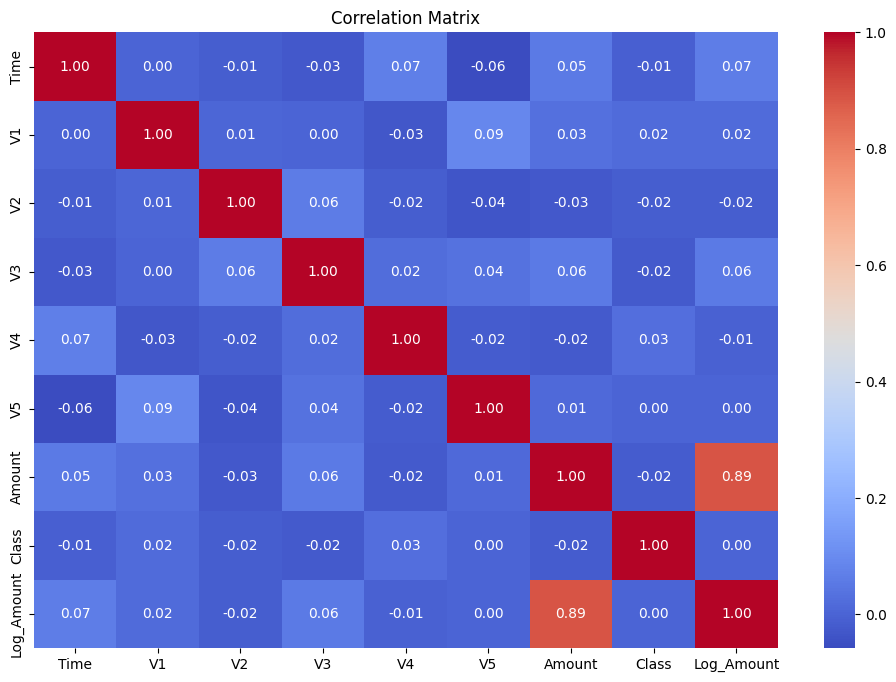

In [23]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

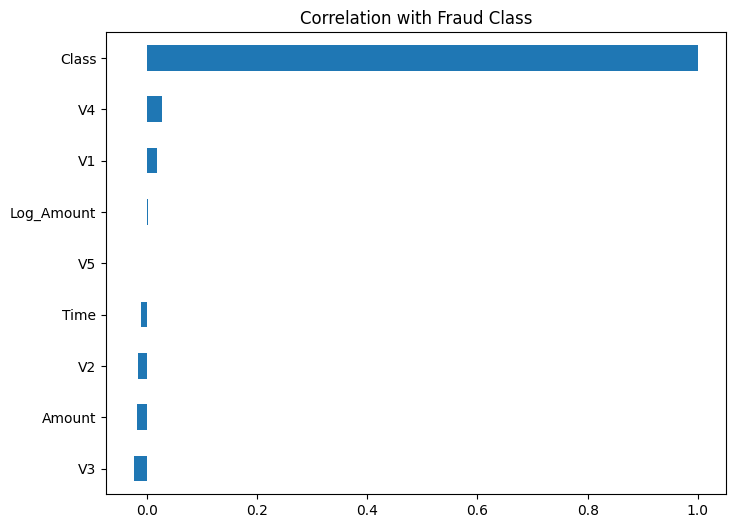

In [24]:
corr_target = (
    df.corr(numeric_only=True)['Class']
    .sort_values()
)

plt.figure(figsize=(8,6))

corr_target.plot(
    kind='barh'
)

plt.title("Correlation with Fraud Class")
plt.show()

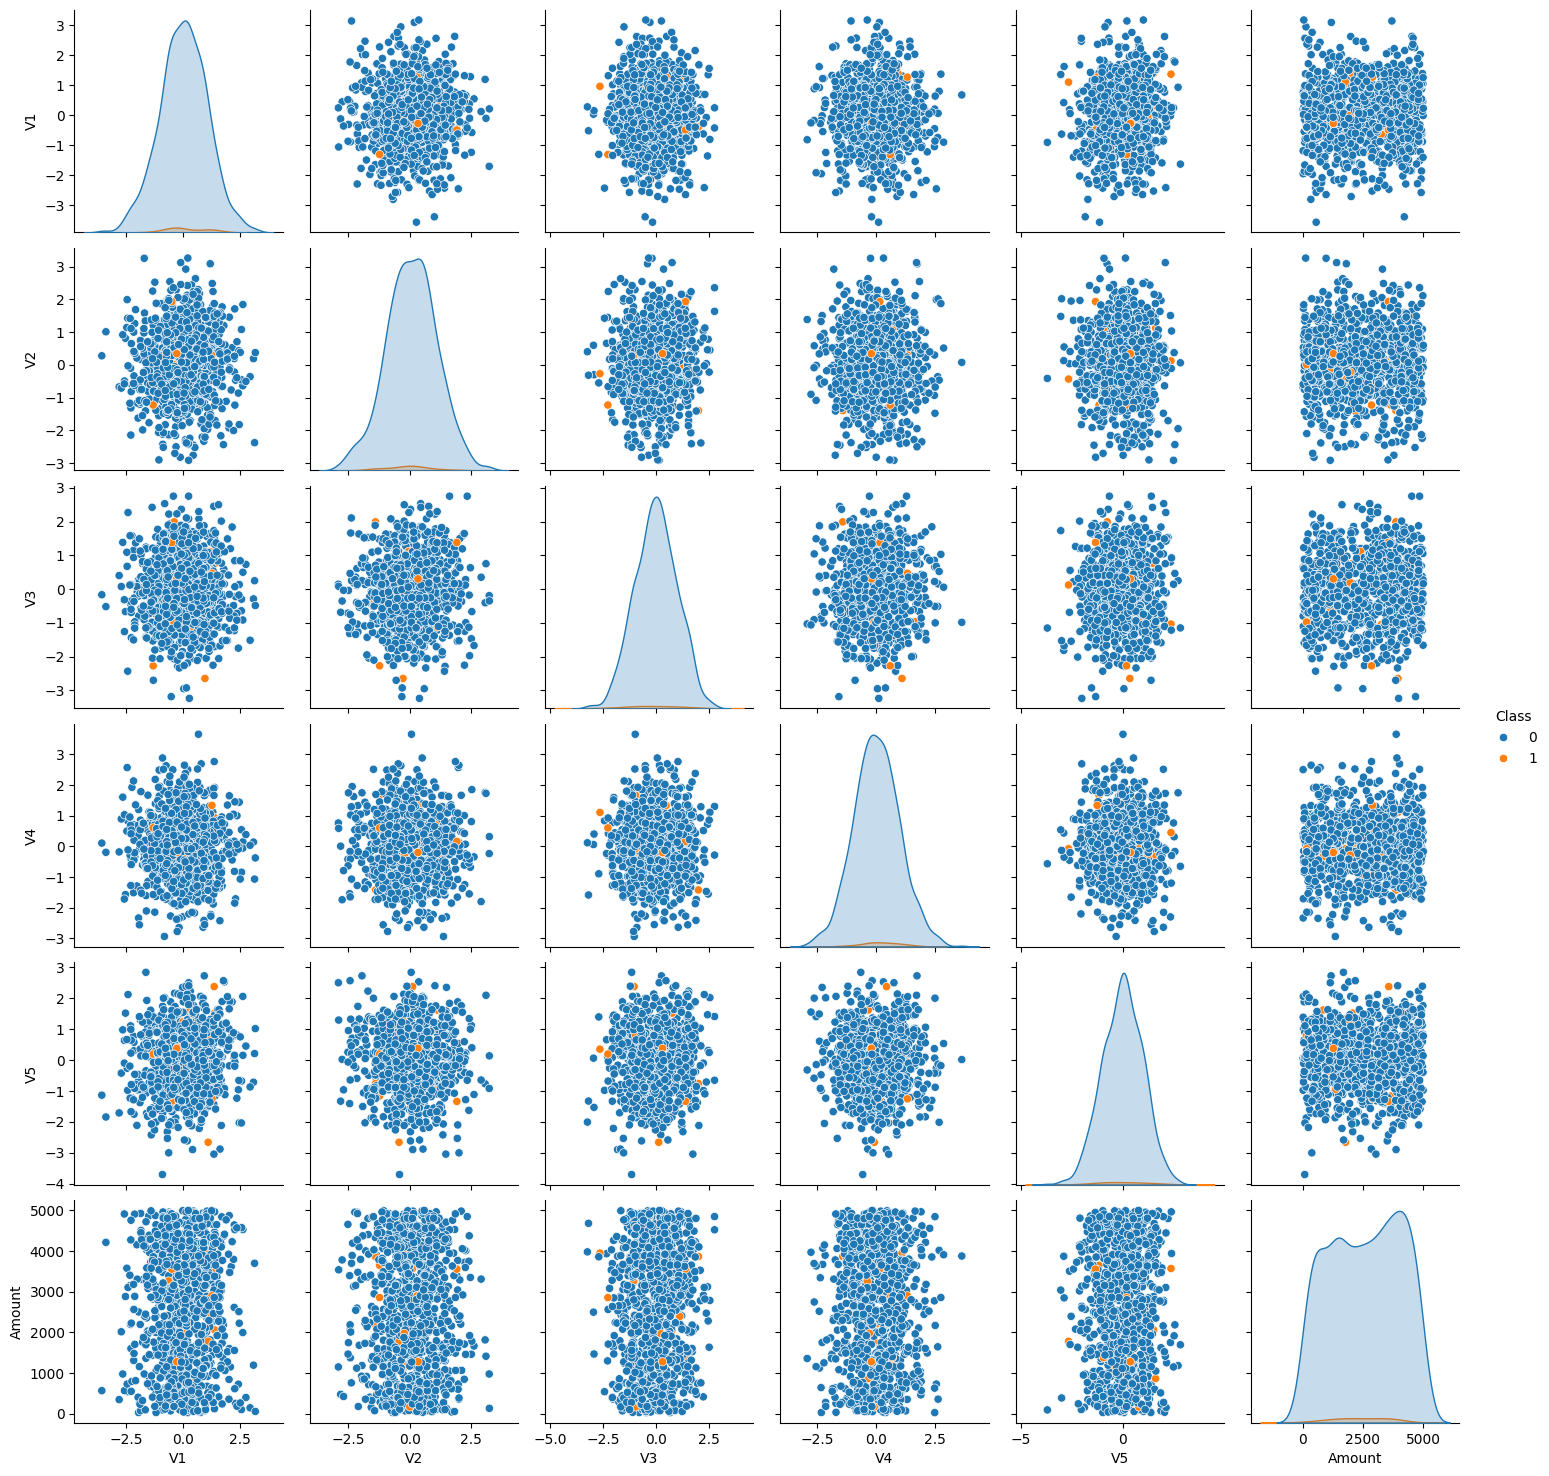

In [25]:
sample_df = df.sample(
    min(5000,len(df)),
    random_state=42
)

sns.pairplot(
    sample_df[
        ['V1','V2','V3','V4','V5','Amount','Class']
    ],
    hue='Class'
)

plt.show()

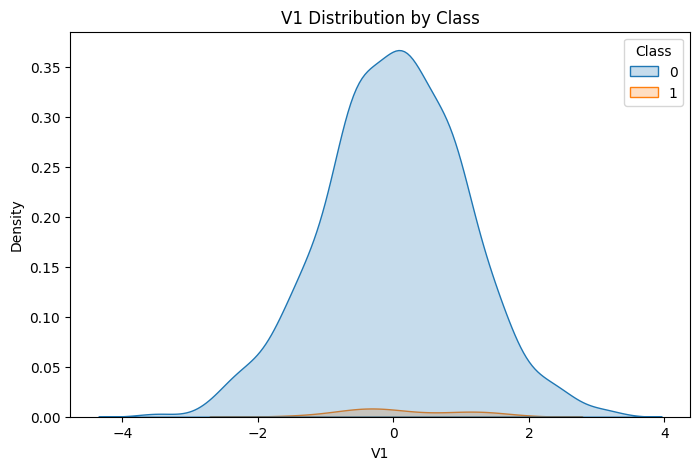

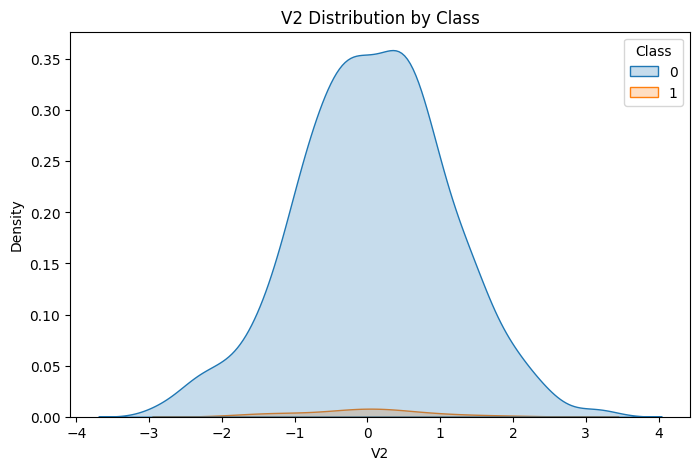

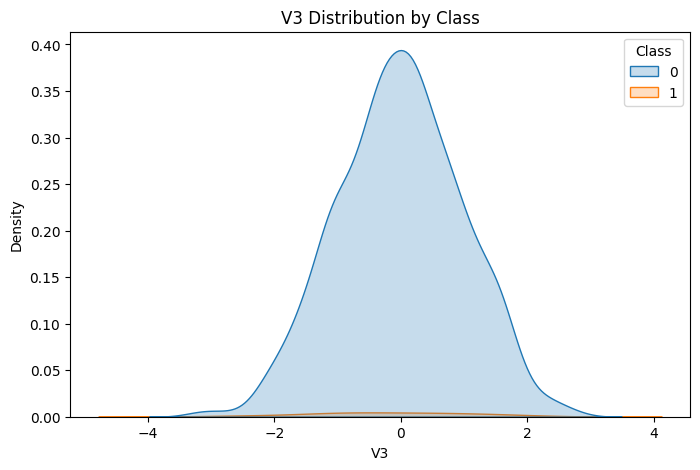

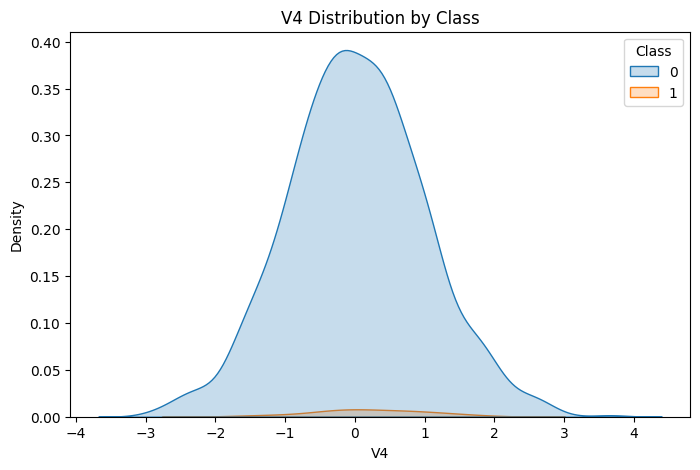

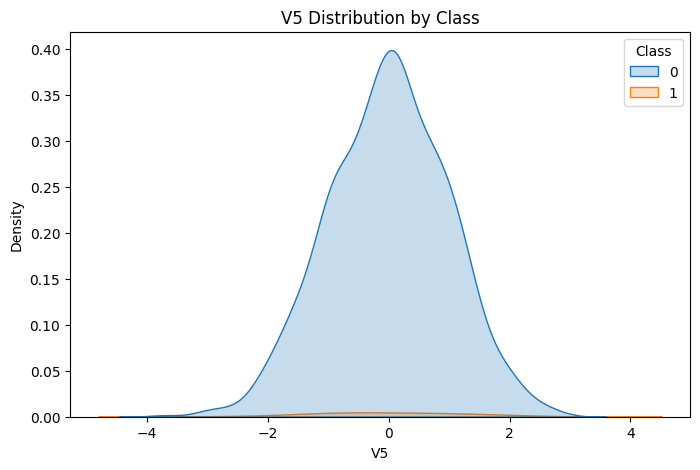

In [26]:
features = ['V1','V2','V3','V4','V5']

for col in features:

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=col,
        hue='Class',
        fill=True
    )

    plt.title(f"{col} Distribution by Class")

    plt.show()

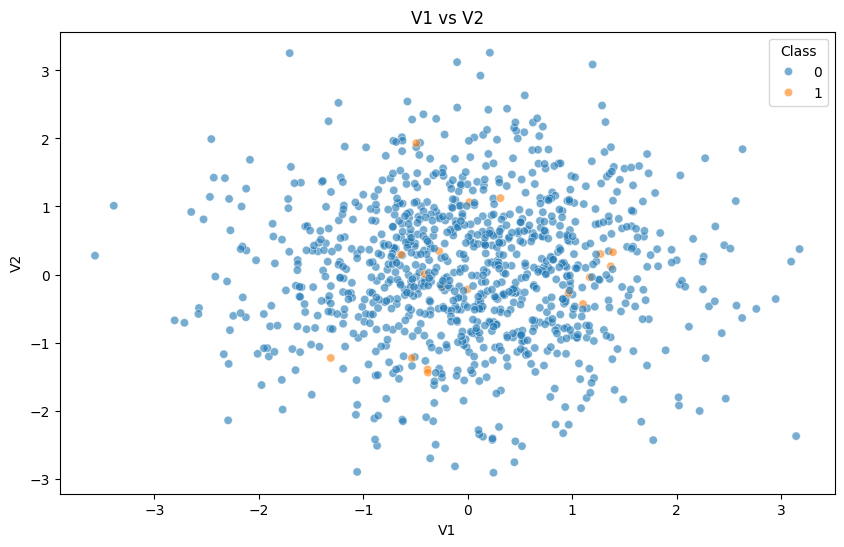

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='V1',
    y='V2',
    hue='Class',
    data=df,
    alpha=0.6
)

plt.title("V1 vs V2")
plt.show()

In [28]:
fraud_pct = (
    df['Class'].mean()*100
)

print(
    f"Fraud Percentage: {fraud_pct:.4f}%"
)

Fraud Percentage: 1.8000%


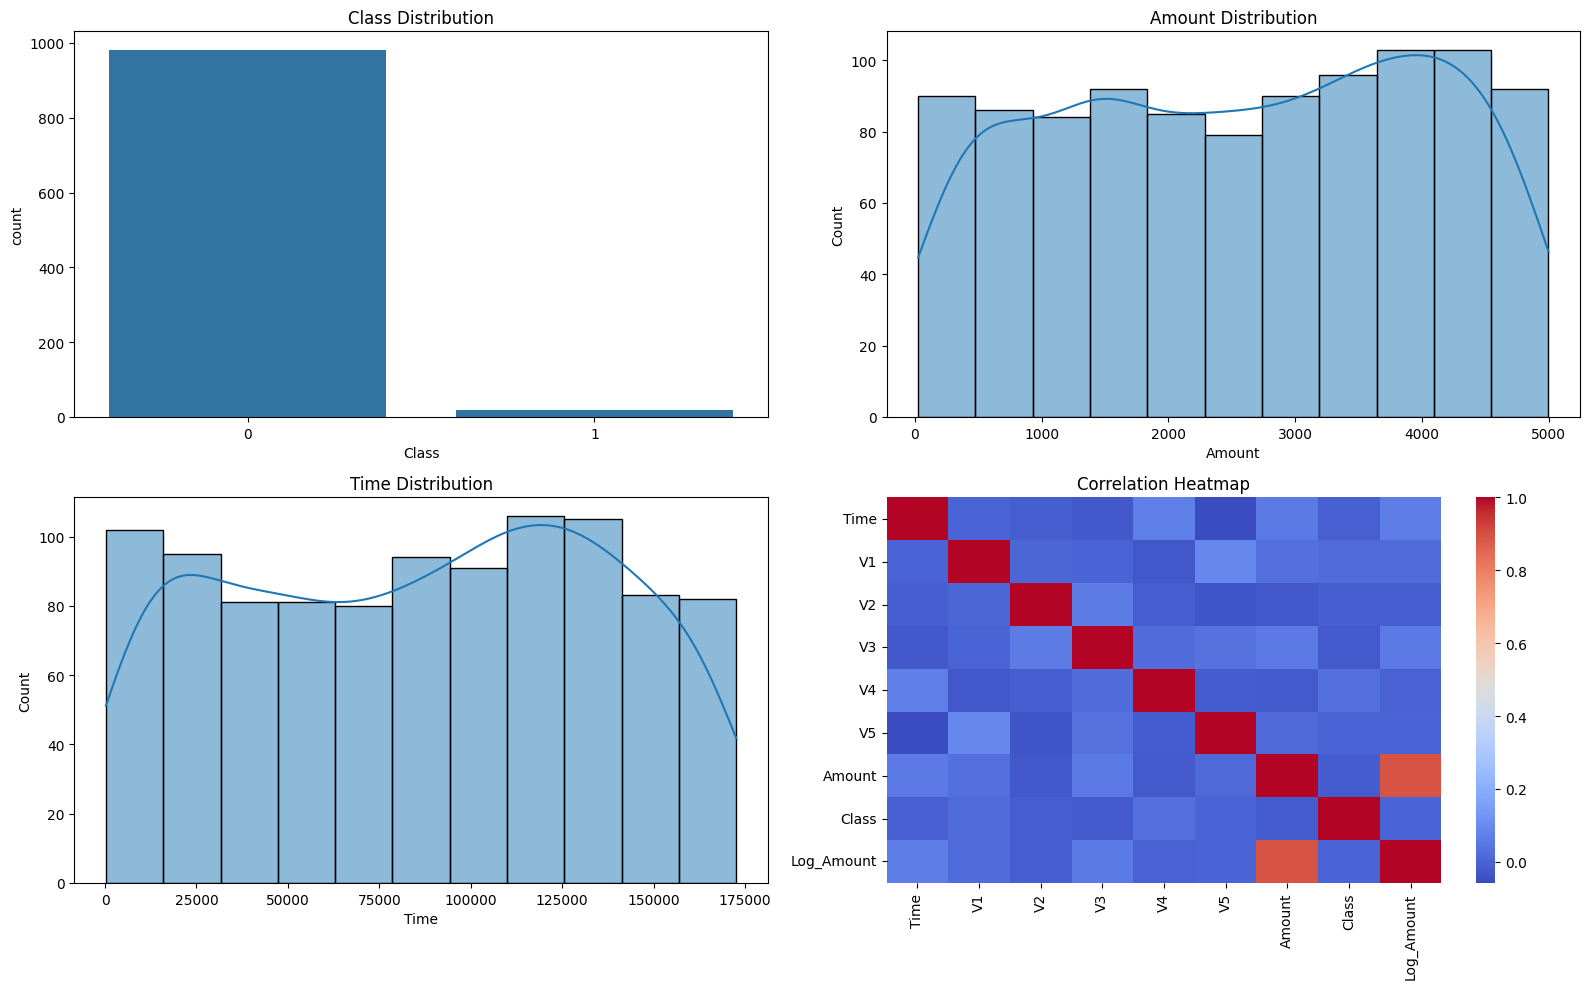

In [29]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16,10)
)

# Class Distribution
sns.countplot(
    x='Class',
    data=df,
    ax=axes[0,0]
)

axes[0,0].set_title("Class Distribution")

# Amount
sns.histplot(
    df['Amount'],
    kde=True,
    ax=axes[0,1]
)

axes[0,1].set_title("Amount Distribution")

# Time
sns.histplot(
    df['Time'],
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Time Distribution")

# Correlation
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    ax=axes[1,1]
)

axes[1,1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Feature engineering

In [30]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier


In [31]:
target = "Class"

X = df.drop(columns=[target])
y = df[target]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 8)
y Shape: (1000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (800, 8)
Testing Shape : (200, 8)


In [33]:
print("Train Distribution")
print(y_train.value_counts(normalize=True))

print("\nTest Distribution")
print(y_test.value_counts(normalize=True))

Train Distribution
Class
0    0.9825
1    0.0175
Name: proportion, dtype: float64

Test Distribution
Class
0    0.98
1    0.02
Name: proportion, dtype: float64


In [34]:
models = {

    "Logistic Regression":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression())
    ]),

    "KNN":
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree":
    Pipeline([
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]),

    "Random Forest":
    Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "Gradient Boosting":
    Pipeline([
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

Logistic Regression
Accuracy : 0.98
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.3712

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



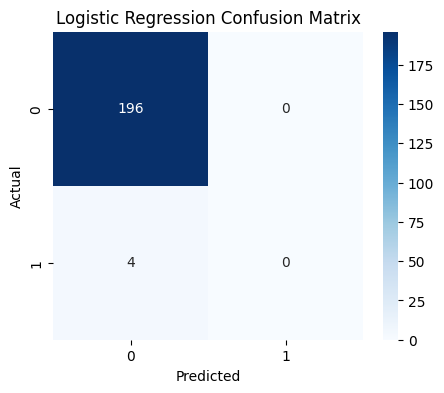

KNN
Accuracy : 0.98
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4413

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



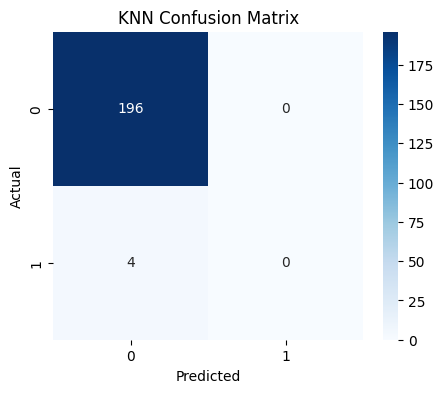

Decision Tree
Accuracy : 0.965
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4923

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       196
           1       0.00      0.00      0.00         4

    accuracy                           0.96       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.96      0.96      0.96       200



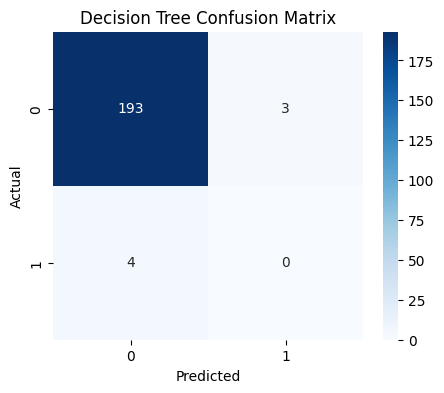

Random Forest
Accuracy : 0.98
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.6945

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



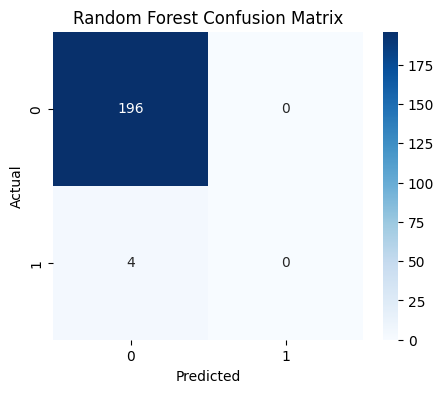

Gradient Boosting
Accuracy : 0.98
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.4222

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.98       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.98      0.97       200



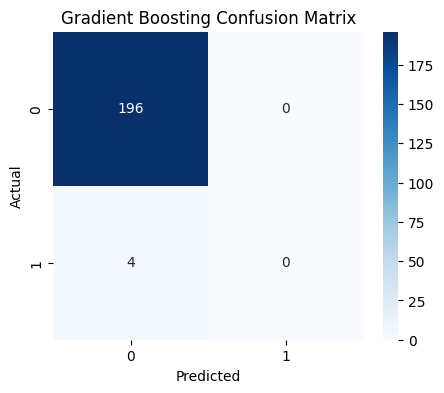

In [35]:
results = []

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc_auc,4))

    print("\nClassification Report")
    print(classification_report(
        y_test,
        y_pred
    ))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [36]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
3        Random Forest     0.980        0.0     0.0       0.0  0.694515
2        Decision Tree     0.965        0.0     0.0       0.0  0.492347
1                  KNN     0.980        0.0     0.0       0.0  0.441327
4    Gradient Boosting     0.980        0.0     0.0       0.0  0.422194
0  Logistic Regression     0.980        0.0     0.0       0.0  0.371173


In [37]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
3        Random Forest     0.980        0.0     0.0       0.0  0.694515
2        Decision Tree     0.965        0.0     0.0       0.0  0.492347
1                  KNN     0.980        0.0     0.0       0.0  0.441327
4    Gradient Boosting     0.980        0.0     0.0       0.0  0.422194
0  Logistic Regression     0.980        0.0     0.0       0.0  0.371173


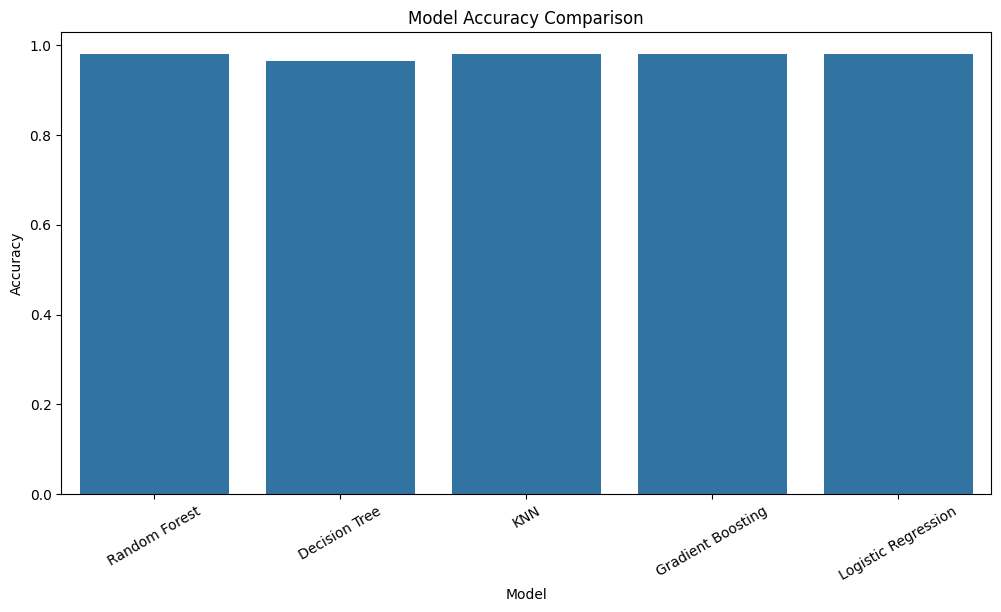

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=30)

plt.title("Model Accuracy Comparison")

plt.show()

<Figure size 1000x800 with 0 Axes>

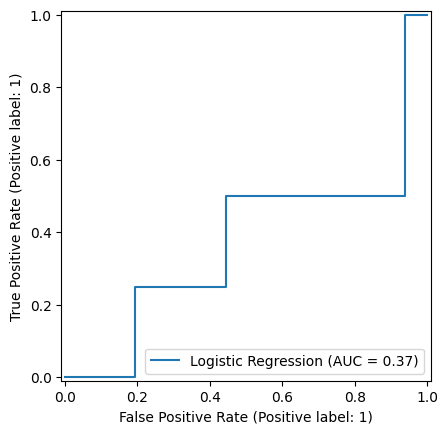

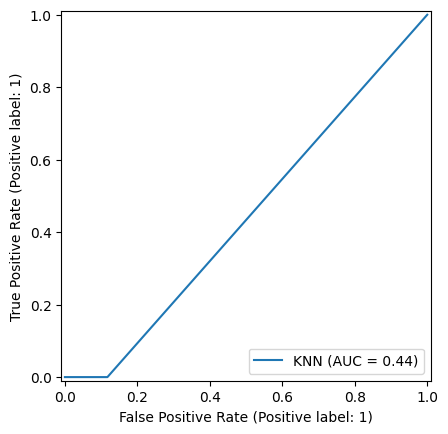

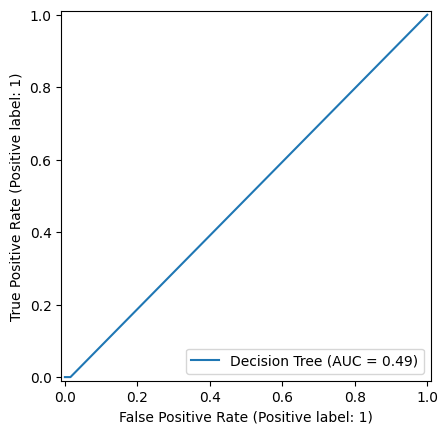

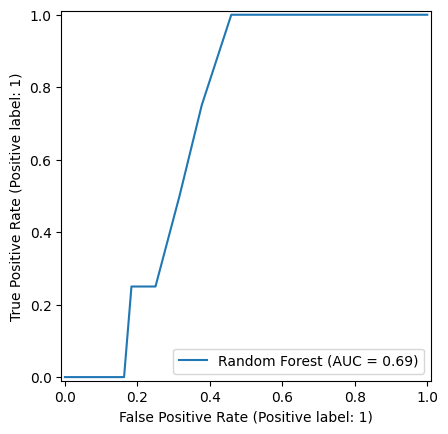

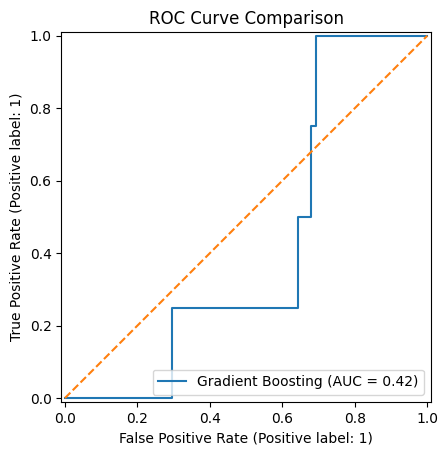

In [39]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)[:,1]

        RocCurveDisplay.from_predictions(
            y_test,
            y_prob,
            name=name
        )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title("ROC Curve Comparison")

plt.show()

In [40]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

print(
    results_df[
        results_df["Model"] == best_model_name
    ]
)

Best Model: Random Forest
           Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
3  Random Forest      0.98        0.0     0.0       0.0  0.694515


      Feature  Importance
5          V5    0.157208
0        Time    0.129270
2          V2    0.122867
7  Log_Amount    0.122846
3          V3    0.120159
4          V4    0.119092
1          V1    0.116207
6      Amount    0.112352


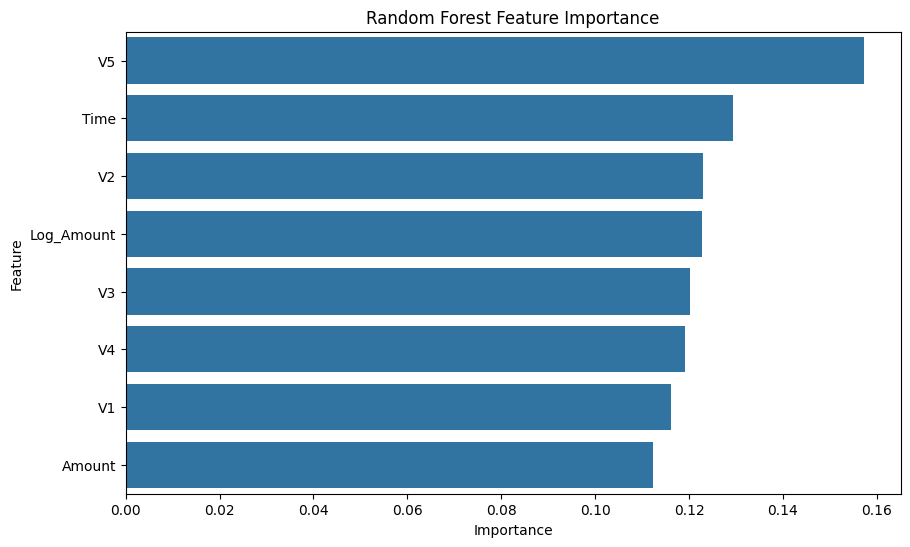

In [41]:
rf_model = models["Random Forest"]

rf_model.fit(
    X_train,
    y_train
)

importances = rf_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": importances

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [42]:
print(df["Class"].value_counts())

print(
    df["Class"].value_counts(normalize=True)*100
)

Class
0    982
1     18
Name: count, dtype: int64
Class
0    98.2
1     1.8
Name: proportion, dtype: float64


In [43]:
class_weight="balanced"

In [44]:
LogisticRegression(
    class_weight="balanced",
    random_state=42
)

RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

RandomForestClassifier(class_weight='balanced', random_state=42)

## Thank you...pls upvote!!!!!!!!!1